<a href="https://colab.research.google.com/github/NaraDaibes/Predictions-Of-Product-Sales/blob/Predictions-Of-Product-Sales/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Predictions

In [59]:
import  pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split,  GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn import set_config
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
set_config(display='diagram')

* Loading Data

In [60]:

file='/content/drive/MyDrive/AXSOSACADEMY (1)/AXSOSACADEMY/02-IntroML/Week05/Data/sales_predictions_2023.csv'
df=pd.read_csv(file)
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


# Data Cleaning

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [62]:
# num of rows and columns
df.shape

(8523, 12)

In [63]:
# data types
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [64]:
# data cleaning duplicate
df.duplicated().sum()


np.int64(0)

In [65]:
# drop duplicates
df= df.drop_duplicates()

In [66]:
# identify missing values
df.isna().sum()


,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [67]:
# check the numerical columns
df.describe()



,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [68]:
# find and fix any inconsistent categories of data # 7
df.nunique()


,0
Item_Identifier,1559
Item_Weight,415
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3


In [69]:
df['Outlet_Size'].isna().sum()

np.int64(2410)

In [70]:
df['Outlet_Location_Type'].isna().sum()

np.int64(0)

In [71]:
df['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [72]:
df['Outlet_Location_Type'].value_counts()

,count
Outlet_Location_Type,
Tier 3,3350
Tier 2,2785
Tier 1,2388


In [73]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [74]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})


In [75]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


* Visualizations

Text(0.5, 1.0, 'Correlation Heatmap')

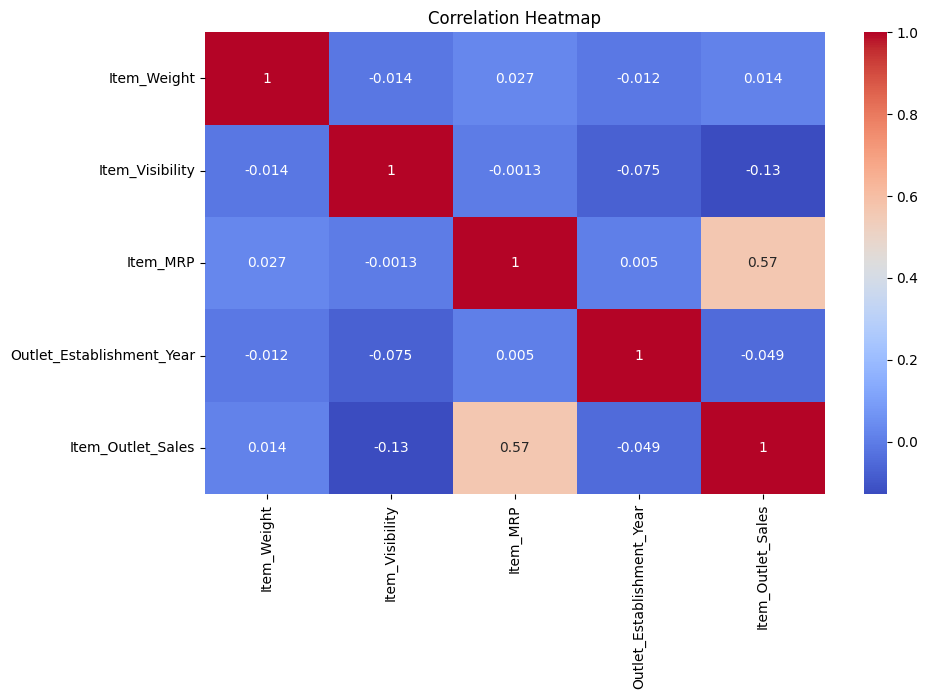

In [76]:
# plot
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

<Axes: xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>

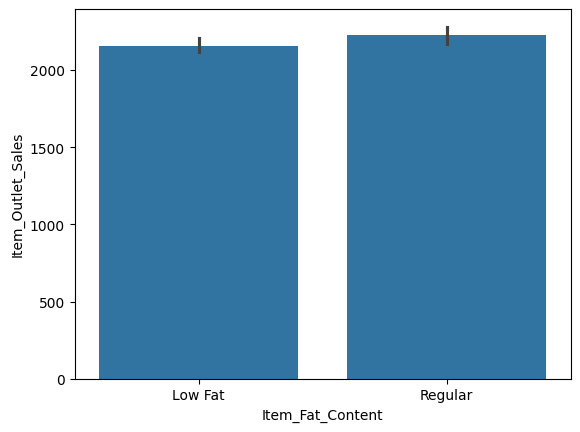

In [77]:
# plot
sns.barplot(x='Item_Fat_Content', y='Item_Outlet_Sales',data=df)

data split

In [78]:
X= df.drop(columns=['Item_Outlet_Sales','Item_Identifier'])
y=df['Item_Outlet_Sales']
X_train,X_test,y_train,y_test= train_test_split(X,y,random_state=42)

* Preprocessing

In [79]:
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse= np.sqrt(mse)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    # Print Result with Label and Header
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  # Get predictions for training data
  y_train_pred = reg.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = reg.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  # Store results in a dataframe if ouput_frame is True
  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    # Set the label as the index
    results_df = results_df.set_index('Label')
    # Set index.name to none to get a cleaner looking result
    results_df.index.name=None
    # Return the dataframe
    return results_df.round(3)

In [80]:
# column transformer
# numeric features
num_col=X_train.select_dtypes('number').columns
impute_median=SimpleImputer(strategy='median')
scaler=StandardScaler()
num_pipe=make_pipeline(impute_median,scaler)
num_tuple=('numeric', num_pipe,num_col)

# CATEGORICAL
cat_col=X_train.select_dtypes('object').columns.drop(['Outlet_Size', 'Outlet_Location_Type'])
impute_Na=SimpleImputer(strategy='constant',fill_value='NA')
ohe_encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
cat_scaler=StandardScaler()
cat_pipe=make_pipeline(impute_Na,ohe_encoder, cat_scaler)
cat_tuple=('categorical',cat_pipe,cat_col)

#Ordinal features
ord_col=['Outlet_Size', 'Outlet_Location_Type']
impute_Na_ord=SimpleImputer(strategy='constant',fill_value='NA')
qual_col_order1=['Small','Medium','High', 'NA'] # Include 'NA' in categories for Outlet_Size
qual_col_order2=['Tier 1','Tier 2','Tier 3']
ordinal_cat_orders=[qual_col_order1,qual_col_order2]
ohe_encoder_ord=OrdinalEncoder(categories=ordinal_cat_orders)
scaler_ord=StandardScaler()
ord_pipe=make_pipeline(impute_Na_ord, ohe_encoder_ord,scaler_ord)
ord_tuple=('ordinal',ord_pipe,ord_col)

# column transformer
col_transformer=ColumnTransformer([num_tuple,cat_tuple, ord_tuple],remainder='drop' )
col_transformer.fit(X_train)
x_train_transformed=col_transformer.transform(X_train)
x_test_transformed=col_transformer.transform(X_test)

* Linear regression model

In [81]:
lin_reg=LinearRegression()
lin_reg.fit(x_train_transformed,y_train)

LinearRegression()

In [82]:
lin_reg.intercept_.round(2)
lin_reg.coef_.round(2)

array([-8.1900e+00, -2.1650e+01,  9.8451e+02, -2.5290e+01, -1.4970e+01,
        1.4970e+01,  2.1000e-01, -4.5500e+00,  5.2600e+00,  7.4700e+00,
       -2.8520e+01, -2.9000e-01,  1.6540e+01,  2.3600e+00,  6.6600e+00,
        1.9600e+00, -2.3500e+00, -3.6700e+00,  2.6520e+01, -7.3800e+00,
       -8.5800e+00,  5.8700e+00, -2.1550e+02, -5.8900e+00,  4.6310e+01,
       -2.5840e+01, -1.9971e+02,  2.3281e+02,  3.0480e+01, -2.5400e+00,
       -9.0000e-01,  4.4840e+01, -3.0404e+02,  7.3260e+01, -2.5840e+01,
        2.3281e+02, -3.6420e+01,  5.5170e+01])

In [83]:
features_names= col_transformer.get_feature_names_out()
features_names

array(['numeric__Item_Weight', 'numeric__Item_Visibility',
       'numeric__Item_MRP', 'numeric__Outlet_Establishment_Year',
       'categorical__Item_Fat_Content_Low Fat',
       'categorical__Item_Fat_Content_Regular',
       'categorical__Item_Type_Baking Goods',
       'categorical__Item_Type_Breads',
       'categorical__Item_Type_Breakfast',
       'categorical__Item_Type_Canned', 'categorical__Item_Type_Dairy',
       'categorical__Item_Type_Frozen Foods',
       'categorical__Item_Type_Fruits and Vegetables',
       'categorical__Item_Type_Hard Drinks',
       'categorical__Item_Type_Health and Hygiene',
       'categorical__Item_Type_Household', 'categorical__Item_Type_Meat',
       'categorical__Item_Type_Others', 'categorical__Item_Type_Seafood',
       'categorical__Item_Type_Snack Foods',
       'categorical__Item_Type_Soft Drinks',
       'categorical__Item_Type_Starchy Foods',
       'categorical__Outlet_Identifier_OUT010',
       'categorical__Outlet_Identifier_OUT013',

In [84]:
coeffs=pd.Series(lin_reg.coef_,index=features_names)
coeffs.round(2)

,0
numeric__Item_Weight,-8.19
numeric__Item_Visibility,-21.65
numeric__Item_MRP,984.51
numeric__Outlet_Establishment_Year,-25.29
categorical__Item_Fat_Content_Low Fat,-14.97
categorical__Item_Fat_Content_Regular,14.97
categorical__Item_Type_Baking Goods,0.21
categorical__Item_Type_Breads,-4.55
categorical__Item_Type_Breakfast,5.26
categorical__Item_Type_Canned,7.47


In [85]:
evaluate_regression(lin_reg,x_train_transformed,y_train,x_test_transformed,y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 847.129
- MSE = 1,297,558.136
- RMSE = 1,139.104
- R^2 = 0.562

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 804.120
- MSE = 1,194,349.715
- RMSE = 1,092.863
- R^2 = 0.567


In [86]:
y_prediction_train=lin_reg.predict(x_train_transformed)
y_prediction_test=lin_reg.predict(x_test_transformed)
features_names = col_transformer.get_feature_names_out()
prediction = pd.DataFrame(x_test_transformed, columns=features_names)
prediction['true_sales']=y_test.values
prediction['predicted_sales']=y_prediction_test.round(1)
prediction['Error']=(y_prediction_test-y_test.values).round(1)
prediction.head()

,numeric__Item_Weight,numeric__Item_Visibility,numeric__Item_MRP,numeric__Outlet_Establishment_Year,categorical__Item_Fat_Content_Low Fat,categorical__Item_Fat_Content_Regular,categorical__Item_Type_Baking Goods,categorical__Item_Type_Breads,categorical__Item_Type_Breakfast,categorical__Item_Type_Canned,...,categorical__Outlet_Identifier_OUT049,categorical__Outlet_Type_Grocery Store,categorical__Outlet_Type_Supermarket Type1,categorical__Outlet_Type_Supermarket Type2,categorical__Outlet_Type_Supermarket Type3,ordinal__Outlet_Size,ordinal__Outlet_Location_Type,true_sales,predicted_sales,Error
0,0.341372,-0.776646,-0.998816,-1.293807,0.740321,-0.740321,-0.284298,-0.167776,-0.115397,-0.285261,...,-0.343896,-0.377964,0.730976,-0.351809,-0.357121,0.517737,1.084948,1743.0644,1360.6,-382.5
1,-1.169135,0.100317,-1.585194,-0.102145,0.740321,-0.740321,-0.284298,-0.167776,-0.115397,-0.285261,...,-0.343896,-0.377964,0.730976,-0.351809,-0.357121,-1.193861,-1.384777,356.8688,717.5,360.6
2,0.388798,-0.482994,-1.595784,0.136187,-1.350766,1.350766,-0.284298,-0.167776,-0.115397,3.505564,...,2.907855,-0.377964,0.730976,-0.351809,-0.357121,-0.338062,-1.384777,377.5086,881.6,504.0
3,-0.049889,-0.415440,0.506592,-1.532139,-1.350766,1.350766,-0.284298,-0.167776,-0.115397,-0.285261,...,-0.343896,-0.377964,-1.368035,-0.351809,2.800168,-0.338062,1.084948,5778.4782,4235.4,-1543.0
4,-0.632039,-1.047426,0.886725,0.732018,-1.350766,1.350766,-0.284298,-0.167776,-0.115397,-0.285261,...,-0.343896,-0.377964,0.730976,-0.351809,-0.357121,-1.193861,-0.149914,2356.9320,3342.3,985.4


* Random Forest

In [87]:
ranfor=RandomForestRegressor(random_state=42)
ranfor_pipe=make_pipeline(col_transformer,ranfor)
ranfor_pipe.fit(X_train,y_train)
evaluate_regression(ranfor_pipe,X_train,y_train,X_test,y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 296.251
- MSE = 182,487.710
- RMSE = 427.186
- R^2 = 0.938

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 765.465
- MSE = 1,215,885.521
- RMSE = 1,102.672
- R^2 = 0.559


In [88]:
ranfor_pipe.get_params()


{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('numeric',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
          'Outlet_Establishment_Year'],
         dtype='object')),
                                   ('categorical',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='NA',
                                                                   strategy='constant')),
                                                    ('oneh...
                                    Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Ide

In [89]:
param_grid={'randomforestregressor__max_depth':[15,20,25,35,None],
            'randomforestregressor__n_estimators':[10,150,200],
            'randomforestregressor__min_samples_leaf':[1,2,3,4],
            'randomforestregressor__max_features':['sqrt','log2',None]}

In [ ]:
gridsearch=GridSearchCV(ranfor_pipe,param_grid=param_grid,cv=5,n_jobs=-1,verbose=1)
gridsearch.fit(X_train,y_train)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


In [ ]:
gridsearch.best_estimator_
best_ranfor_pipe=gridsearch.best_estimator_
best_ranfor_pipe

In [ ]:
evaluate_regression(best_ranfor_pipe,X_train,y_train,X_test,y_test)
